ODE:
$$\frac{dy(t)}{dt} + 0.05 y(t) = 0.2F(t), \qquad y(0) = 3.1$$
Where $F(t)$ is Real GDP data and $y(t)$ represents capital stock.

## Imports

In [78]:
# Cell 1 - installs + clone
!pip install --quiet torch torchvision jax jaxlib keras_sig numpy matplotlib scipy pytorch-minimize
!git clone https://github.com/CharliePyle4/BSK_ODE.git /content/BSK_ODE 2>/dev/null || git -C /content/BSK_ODE pull

# Cell 2 - import
import sys
sys.path.insert(0, '/content/BSK_ODE')
from bsk_ode.sollow import *
print("Using device:", device, "torch", torch.__version__)


Already up to date.
Using device: cuda torch 2.11.0+cu128


# Problem and Model Parameters

In [79]:
signature_level = 3
lambda_econ = 0.05
n0 = 50
retrain_every = 10
y0 = 3.1


In [80]:

# ── Import GDP data ──────────────────────────────────────────────
os.chdir("/content/BSK_ODE")
df = pd.read_csv("Data/econ_f_t_gdp_normalized_time.csv")
df["t"] = pd.to_datetime(df["t"])

t_forcing = df["t_norm"].to_numpy(dtype=np.float64)  # normalized time
F_raw      = df["f"].to_numpy(dtype=np.float64)      # Real GDP data (F(t))

t_vals = torch.tensor(t_forcing, dtype=torch.float64)
dt     = float(t_forcing[1] - t_forcing[0])
N      = len(t_vals)



F_scaled     = 0.2 * F_raw
F_star_base  = trapezoidal_array(F_scaled, dt)        
F_star       = y0 + np.asarray(F_star_base)           
F_star_torch = torch.tensor(F_star, dtype=torch.float64, device=device)

# This DataFrame replaces integrated_f.csv
forcing_data = pd.DataFrame({
    "t_norm":       t_forcing,
    "f_integrated": F_star,
})

# ── Solve Solow ODE with SciPy ─────
t_solow, y_solow_torch = solve_solow_ivp(
    t_grid        = t_vals,
    F_torch       = torch.tensor(F_raw, dtype=torch.float64),
    y0            = 3.1,
    lambda_econ   = lambda_econ,
    forcing_scale = 0.2,
)
y_solow_np = y_solow_torch.detach().cpu().numpy()
data = {"y_solow": y_solow_np}


# If grids mismatch, interpolate; otherwise just copy
if len(y_solow_torch) != N or not torch.allclose(t_solow, t_vals):
    y_true_interp = interpolate_to_grid(t_solow, y_solow_torch, t_vals)
else:
    y_true_interp = y_solow_torch.clone()




In [81]:
# ── Build prefix paths ────────────────────────────────────────
paths_nb = build_paths_nonbranched(forcing_data, t_lift_exp=1.0)

In [82]:
#  Full-batch calibration ───────────────────────────────────
fb = run_full_batch(
    paths_nb        = paths_nb,
    F_star          = F_star,
    dt              = dt,
    signature_level = signature_level,
    lambda_econ     = lambda_econ,
)
# fb keys: "F_hat", "K_A", "A", "K", "K1"


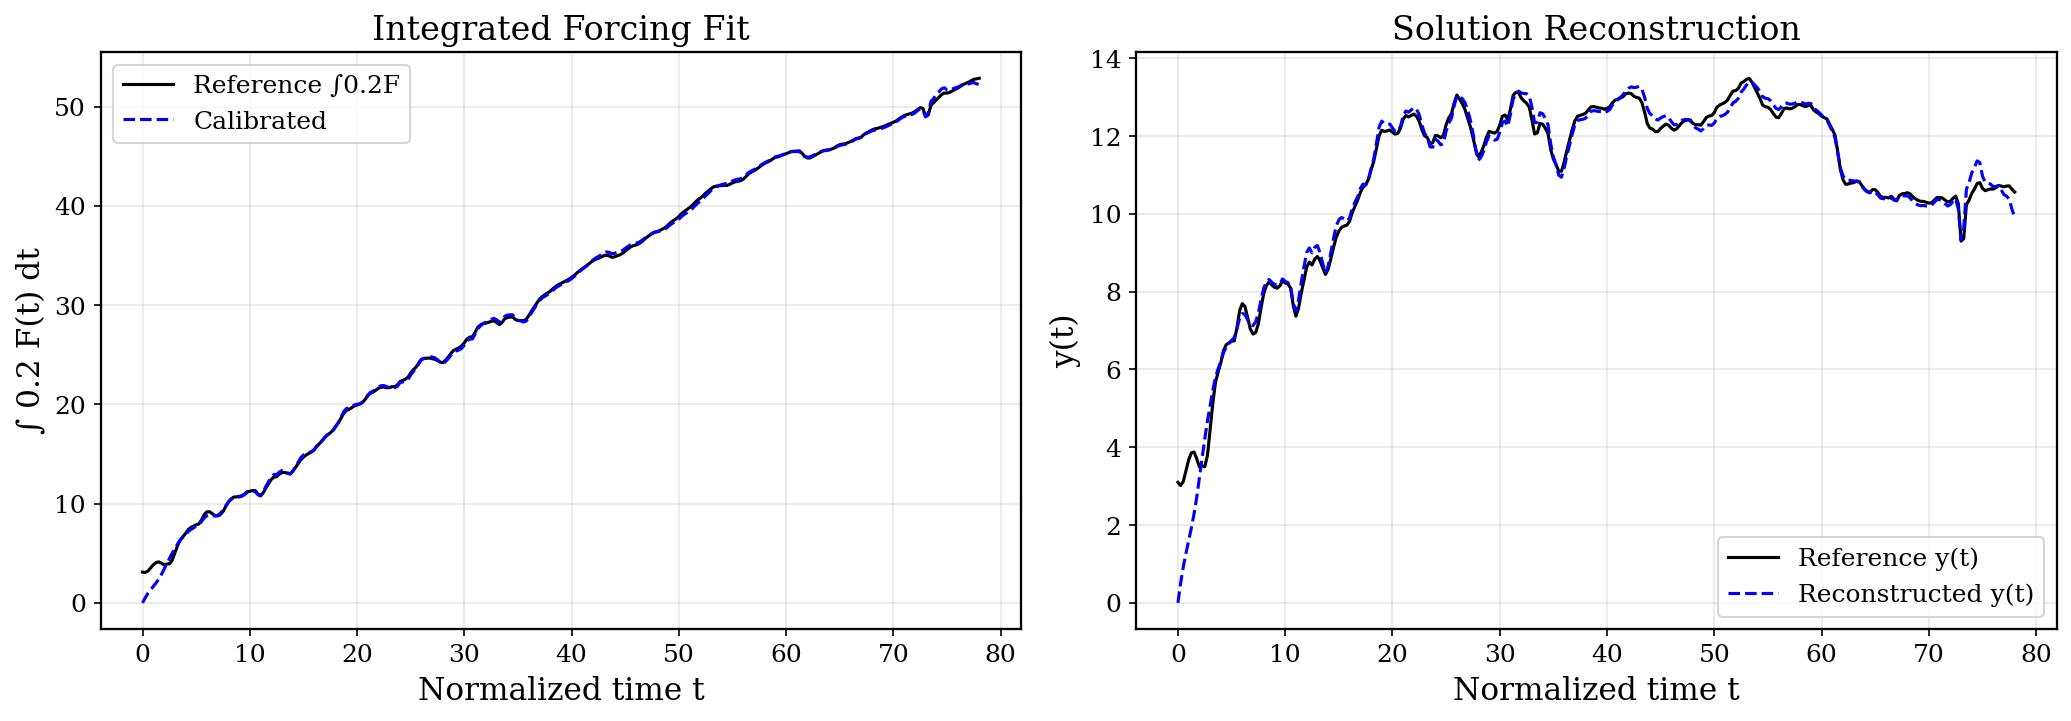

In [83]:
# Plot full-batch results ──────────────────────────────────
plot_calibration(
    time   = t_vals,
    F_star = F_star,
    F_hat  = fb["F_hat"],
    U_true = data["y_solow"],
    U_hat  = fb["K_A"],
)

In [84]:
# Full-batch error summary ─────────────────────────────────
N_full    = len(t_vals)
idx_all   = np.arange(0, N_full)
idx_train = np.arange(0, n0 + 1)
idx_test  = np.arange(n0 + 1, N_full)

print_error_summary(
    label      = "Full-Batch",
    F_pred     = fb["F_hat"],
    F_true     = F_star,
    y_pred     = fb["K_A"],
    y_true     = data["y_solow"],
    idx_train  = idx_train,
    idx_test   = idx_test,
    idx_full   = idx_all,
    use_torch  = False,
)


Full-Batch Error Summary
Quantity                                 MSE       Relative MSE     Relative MSE (%)
--------------------------------------------------------------------------------------
Training forcing                8.193740e-01       1.076890e-02              1.0769%
Training solution               7.801278e-01       1.719009e-02              1.7190%
--------------------------------------------------------------------------------------
Testing forcing                 3.219356e-02       2.363315e-05              0.0024%
Testing solution                3.375201e-02       2.427997e-04              0.0243%
--------------------------------------------------------------------------------------
Full forcing                    1.604562e-01       1.392053e-04              0.0139%
Full solution                   1.553660e-01       1.255423e-03              0.1255%


In [85]:
# Build rolling state ───────────────────────────────────────
state_nb = build_state_nonbranched(
    paths_nb        = paths_nb,
    n0              = n0,
    signature_level = signature_level,
    lambda_econ     = lambda_econ,
    dt              = dt,
    t_vals          = t_vals,
    F_star_torch    = F_star_torch,
    y_true_interp   = y_true_interp,
)

print("Non-branched training done.")

Non-branched training done.


In [86]:
# Run rolling prediction ──────────────────────────────────
res_nb = rolling_online_predict_econ_nonbranched(
    state_nb,
    retrain_every = retrain_every,
)

print("Non-branched rolling prediction done.")

# Build index slices ───────────────────────────────────────
idx_train = torch.arange(0, n0 + 1)
idx_test  = torch.arange(n0 + 1, res_nb["end_idx"] + 1)
idx_full  = torch.arange(0, res_nb["end_idx"] + 1)

[Retrain] at index 60
[Retrain] at index 70
[Retrain] at index 80
[Retrain] at index 90
[Retrain] at index 100
[Retrain] at index 110
[Retrain] at index 120
[Retrain] at index 130
[Retrain] at index 140
[Retrain] at index 150
[Retrain] at index 160
[Retrain] at index 170
[Retrain] at index 180
[Retrain] at index 190
[Retrain] at index 200
[Retrain] at index 210
[Retrain] at index 220
[Retrain] at index 230
[Retrain] at index 240
[Retrain] at index 250
[Retrain] at index 260
[Retrain] at index 270
[Retrain] at index 280
[Retrain] at index 290
[Retrain] at index 300
[Retrain] at index 310
Non-branched rolling prediction done.


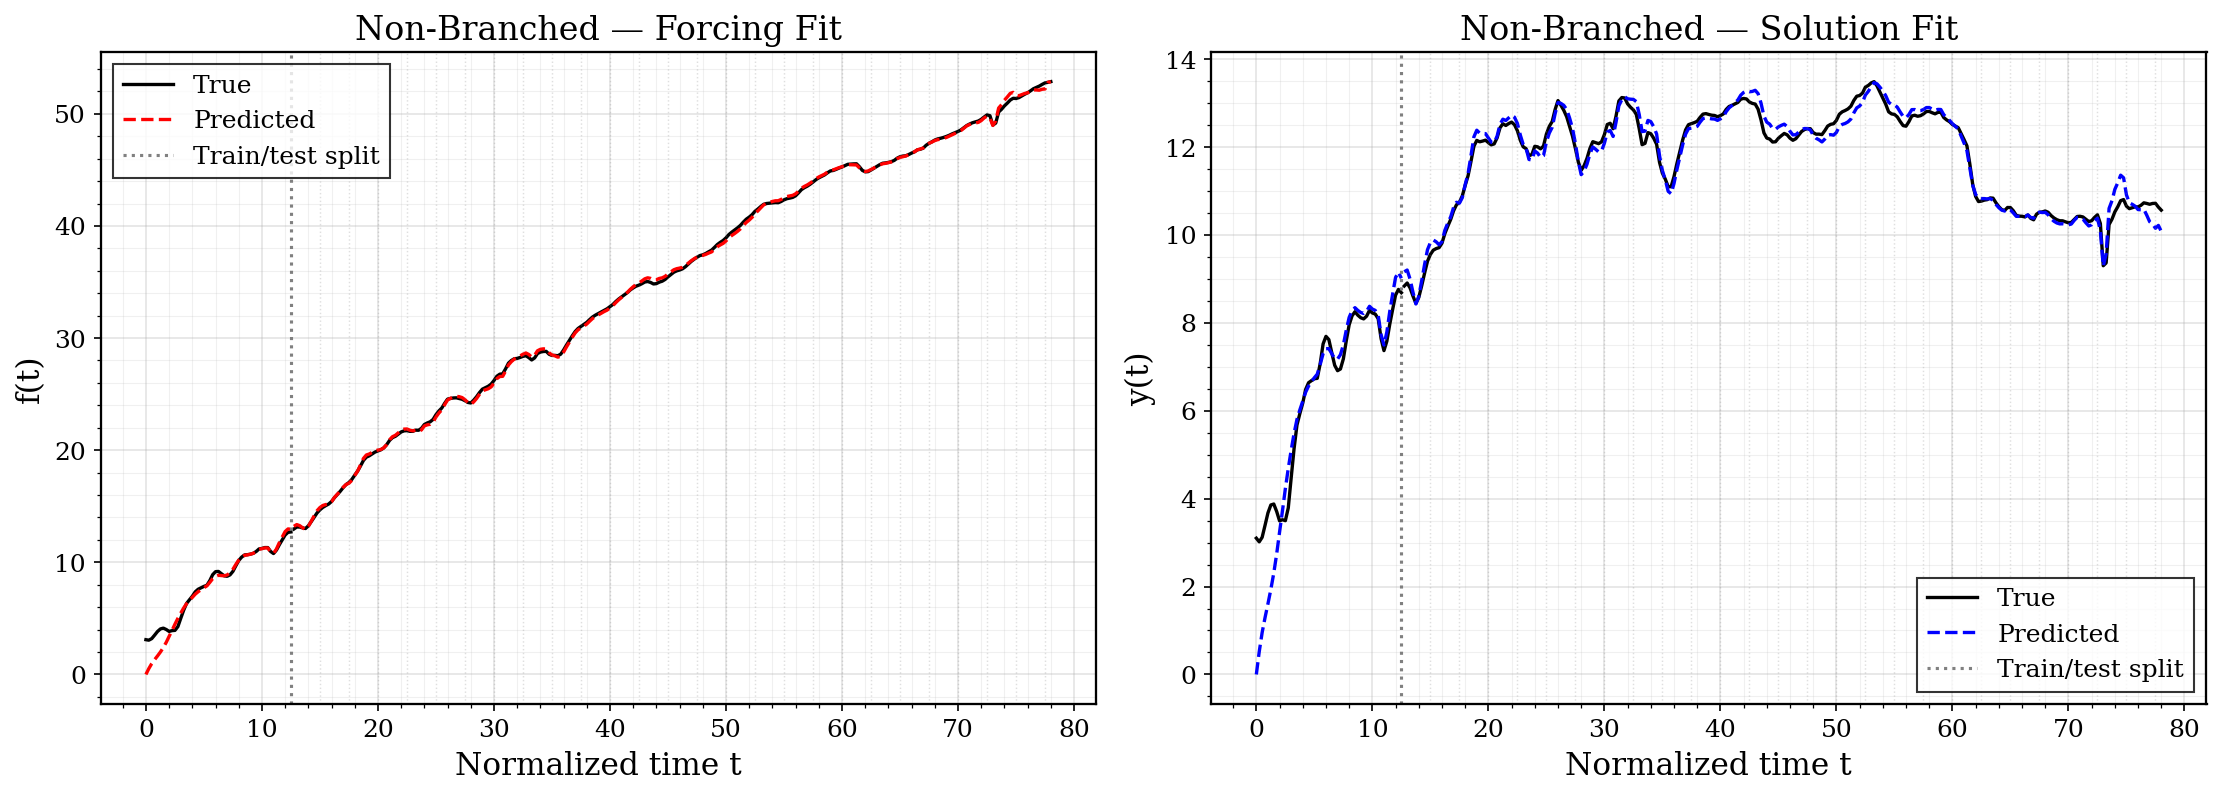

In [87]:
# Plot rolling results ─────────────────────────────────────
plot_rolling_results(
    t_vals        = t_vals,
    n0            = n0,
    F_star_torch  = F_star_torch,
    y_true_interp = y_true_interp,
    res           = res_nb,
    title_prefix  = "Non-Branched — ",
)

In [88]:
# Rolling error summary ───────────────────────────────────
print_error_summary(
    label      = "Non-Branched Rolling",
    F_pred     = res_nb["F_pred"],
    F_true     = F_star_torch,
    y_pred     = res_nb["y_pred"],
    y_true     = y_true_interp,
    idx_train  = idx_train,
    idx_test   = idx_test,
    idx_full   = idx_full,
    use_torch  = True,
)


Non-Branched Rolling Error Summary
Quantity                                 MSE       Relative MSE     Relative MSE (%)
--------------------------------------------------------------------------------------
Training forcing                8.125828e-01       1.067965e-02              1.0680%
Training solution               7.784613e-01       1.715337e-02              1.7153%
--------------------------------------------------------------------------------------
Testing forcing                 2.985662e-02       2.191761e-05              0.0022%
Testing solution                3.263838e-02       2.347887e-04              0.0235%
--------------------------------------------------------------------------------------
Full forcing                    1.573935e-01       1.365482e-04              0.0137%
Full solution                   1.541622e-01       1.245697e-03              0.1246%
